## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_max=10,
# k_bar=10, plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="dyca",
    scaling_mode="global_mean",
    data_dir="data_csv",            # Ordner mit den vier TEP-CSVs

    # DyCA-Stufe: m lineare Komponenten, n Dimension des
    # deterministischen Systems. Randbedingungen des Pakets:
    # n >= m und m >= n - m. Die Schaetzzelle unten hilft
    # bei der Wahl.
    dyca_m=2,
    dyca_n=4,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## m und n schätzen

DyCA braucht zwei Vorgaben: *m* lineare Komponenten und *n* als Dimension des deterministischen Systems. Beide sollten aus den Normalbetriebsdaten abgelesen werden, nicht geraten. Die zwei Diagnoseplots darunter zeigen, was die Daten nahelegen.

Referenz-Run shape: (500, 52)


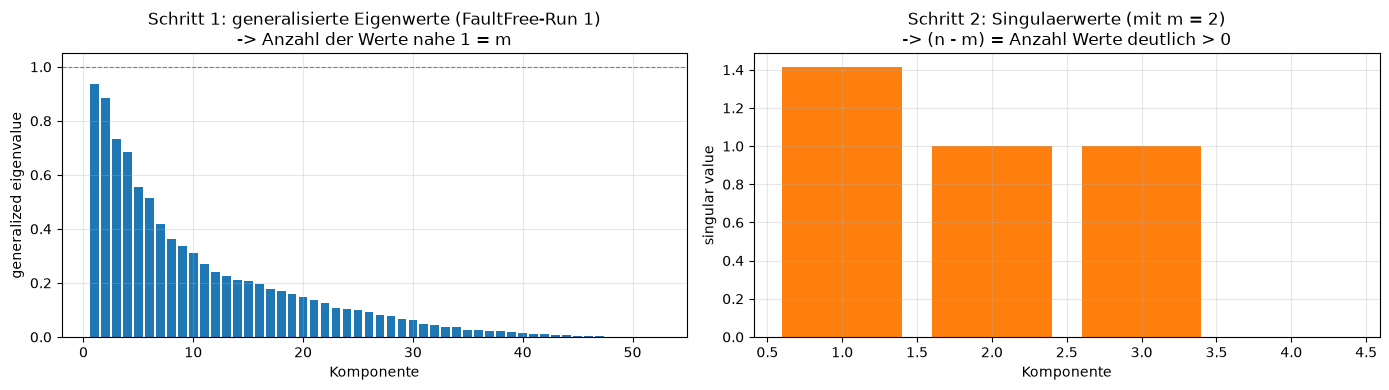


Aktuelle Einstellung: dyca_m = 2, dyca_n = 4
Legen die Plots eine andere Wahl nahe, in der Konfigurations-zelle aendern und neu ausfuehren.


In [4]:
# ============================================================
# m und n aus den FaultFree-Daten schaetzen
# ============================================================
# Links: generalisierte Eigenwerte ohne m-Vorgabe - die Anzahl der Werte
# nahe 1 ist das gesuchte m. Rechts: Singulaerwerte bei vorgegebenem m -
# die Anzahl der deutlich von null verschiedenen Werte ist (n - m).
# Der Referenzlauf wird mit DEMSELBEN scaling_mode vorverarbeitet wie die
# Produktivschleife, Schaetzung und Lauf koennen also nicht auseinander-
# driften.
from tep.eigen import plot_dyca_mn_estimate

_ = plot_dyca_mn_estimate(CFG, df_ff, scaler)

## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [5]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne DyCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10038
Uebersprungen   : 0 (weniger als 9 Samples)
Fehler          : 462
Erste Fehler:
  fault=0, run=22: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=25: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=71: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=105: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=168: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.


,faultNumber,simulationRun,dyca_1,dyca_2,dyca_3,dyca_4,dyca_5,dyca_6,dyca_7,dyca_8,...,dyca_43,dyca_44,dyca_45,dyca_46,dyca_47,dyca_48,dyca_49,dyca_50,dyca_51,dyca_52
0,0,1,0.938135,0.883930,0.732372,0.685325,0.553841,0.514848,0.418447,0.362320,...,0.007479,0.007188,0.004308,0.003296,0.002363,0.001365,0.000447,0.000076,0.000009,0.000004
1,0,2,0.951969,0.930103,0.804481,0.755122,0.531489,0.501349,0.433421,0.402186,...,0.005911,0.005219,0.004505,0.003609,0.002911,0.001903,0.000933,0.000409,0.000246,0.000030
2,0,3,0.931522,0.906693,0.735949,0.715483,0.534500,0.494142,0.413665,0.396511,...,0.007344,0.006405,0.004387,0.003676,0.002929,0.001490,0.001289,0.000049,0.000008,0.000002
3,0,4,0.934332,0.906974,0.774786,0.676038,0.573521,0.499904,0.430269,0.400309,...,0.009029,0.006162,0.005838,0.004478,0.002628,0.001965,0.001028,0.000699,0.000093,0.000001
4,0,5,0.938610,0.878737,0.784141,0.625218,0.530512,0.481130,0.469798,0.413853,...,0.007267,0.006785,0.005568,0.004285,0.003751,0.002599,0.001471,0.000468,0.000049,0.000022


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [6]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte DyCA-Statistiken pro Fault: (21, 105)


,faultNumber,dyca_1_mean,dyca_1_std,dyca_2_mean,dyca_2_std,dyca_3_mean,dyca_3_std,dyca_4_mean,dyca_4_std,dyca_5_mean,...,dyca_48_mean,dyca_48_std,dyca_49_mean,dyca_49_std,dyca_50_mean,dyca_50_std,dyca_51_mean,dyca_51_std,dyca_52_mean,dyca_52_std
0,0,0.931774,0.008262,0.890966,0.017925,0.762670,0.028201,0.667983,0.035838,0.534775,...,0.001359,0.000521,0.000742,0.000377,0.000311,0.000200,0.000085,0.000077,0.000009,0.000016
1,1,0.984894,0.002502,0.957327,0.004753,0.932693,0.007124,0.817945,0.015671,0.710132,...,0.001476,0.000567,0.000815,0.000392,0.000368,0.000231,0.000108,0.000101,0.000014,0.000025
2,2,0.944537,0.005496,0.911176,0.011134,0.811950,0.021732,0.706299,0.023915,0.555901,...,0.001471,0.000518,0.000824,0.000366,0.000379,0.000227,0.000124,0.000107,0.000014,0.000026
3,3,0.932740,0.008356,0.893414,0.017758,0.766107,0.027783,0.673081,0.035510,0.540902,...,0.001435,0.000521,0.000800,0.000371,0.000344,0.000227,0.000098,0.000092,0.000011,0.000020
4,4,0.932719,0.008292,0.893573,0.018022,0.771729,0.027366,0.678563,0.032803,0.580250,...,0.001510,0.000570,0.000834,0.000393,0.000359,0.000233,0.000102,0.000096,0.000011,0.000018


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

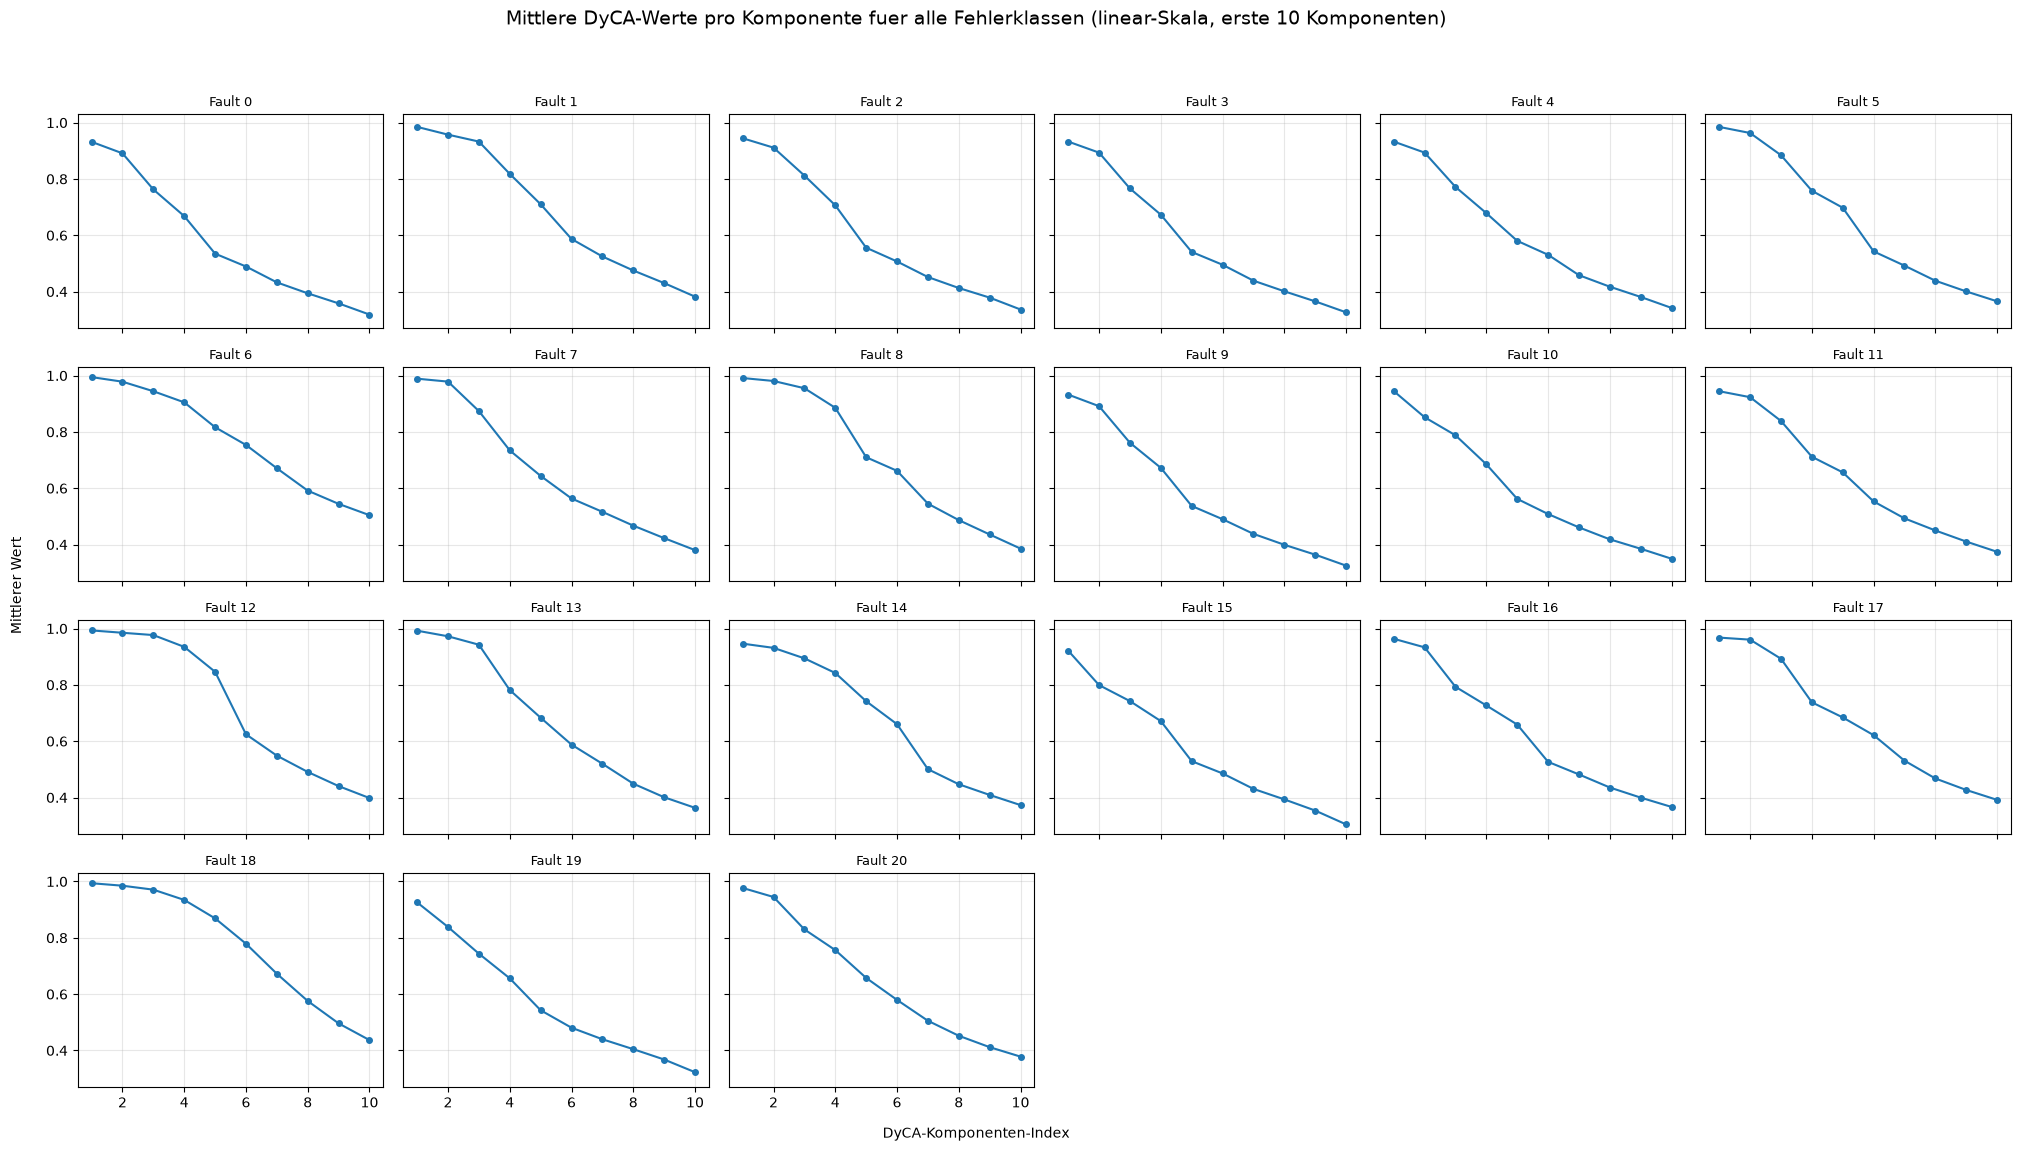

In [7]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

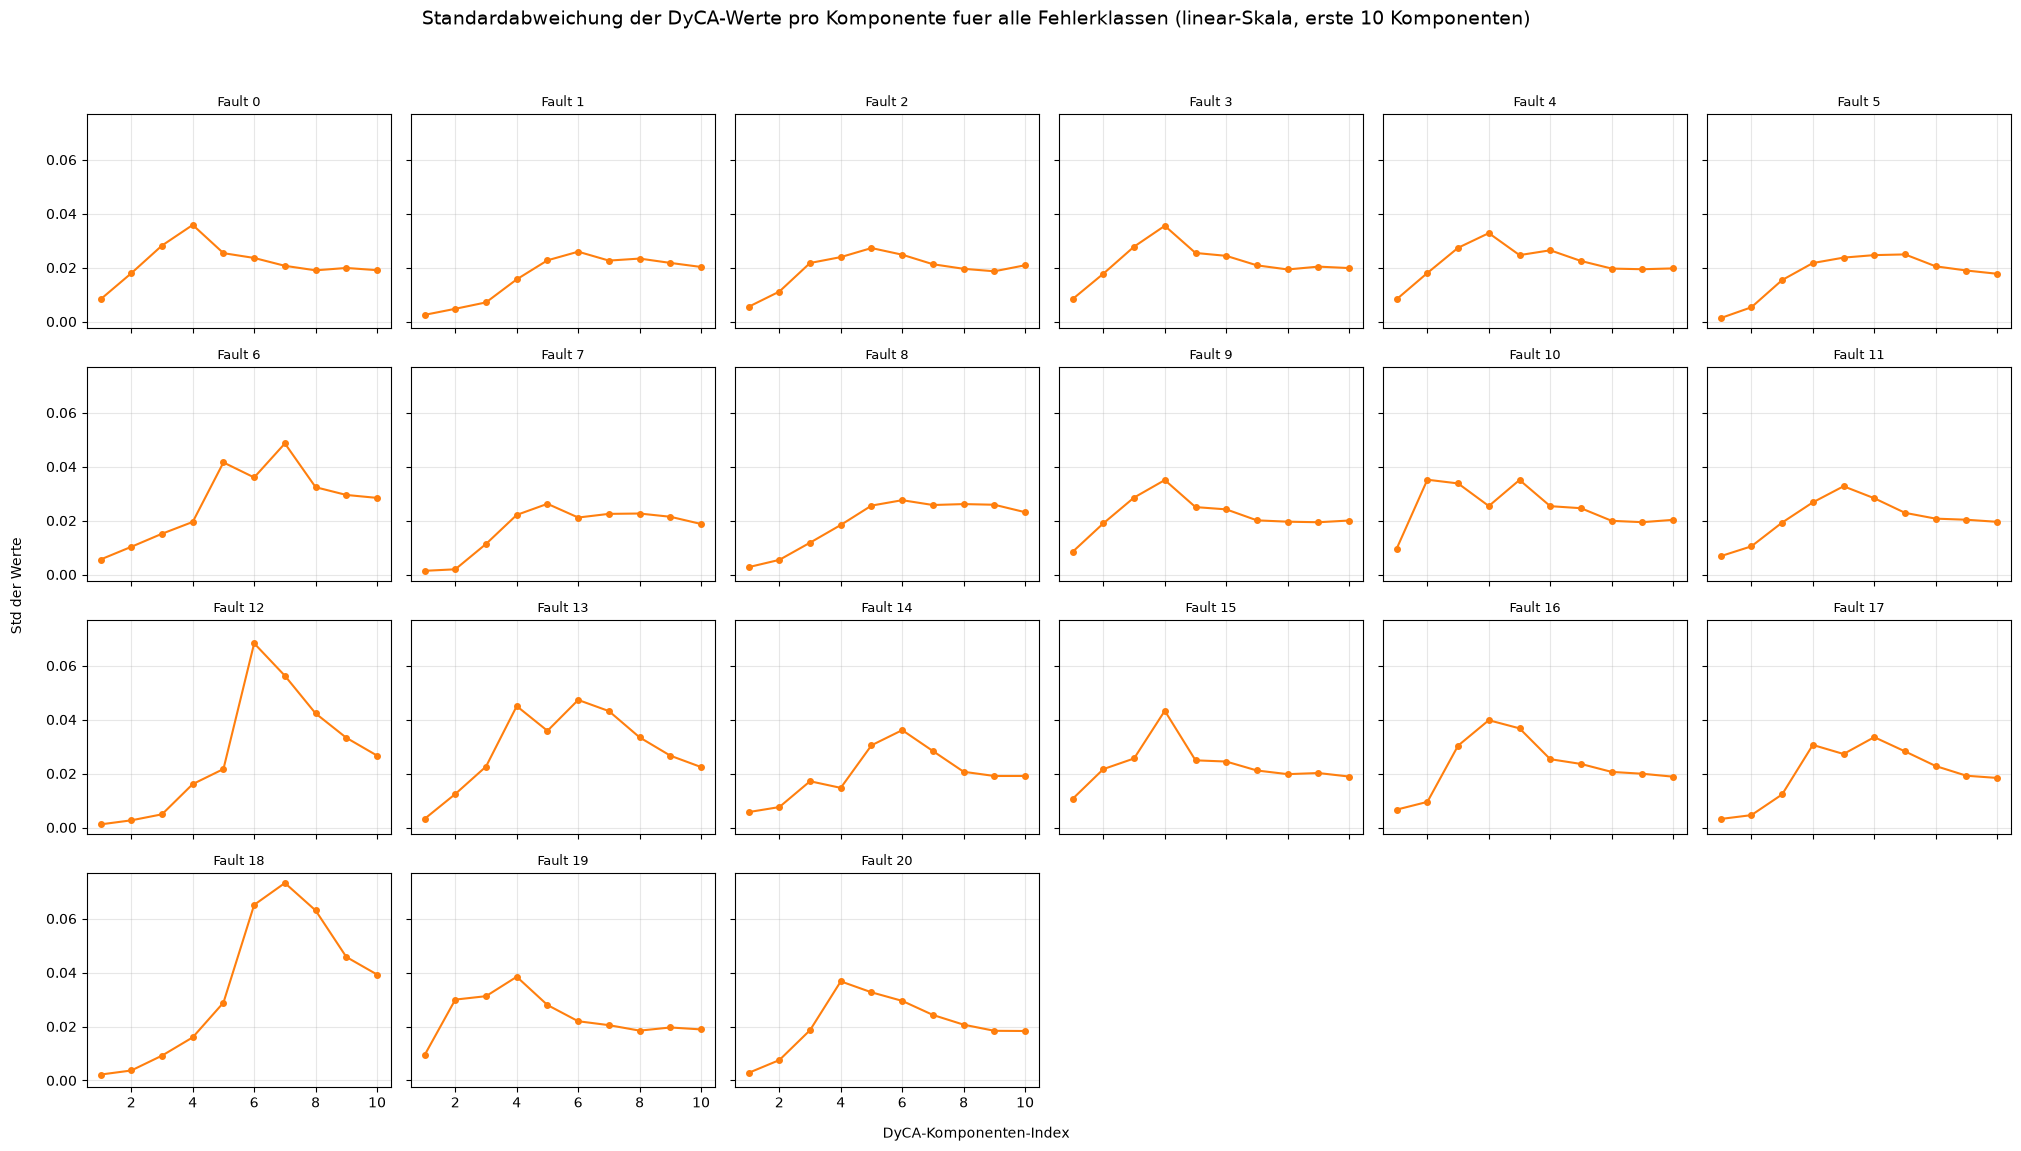

In [8]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

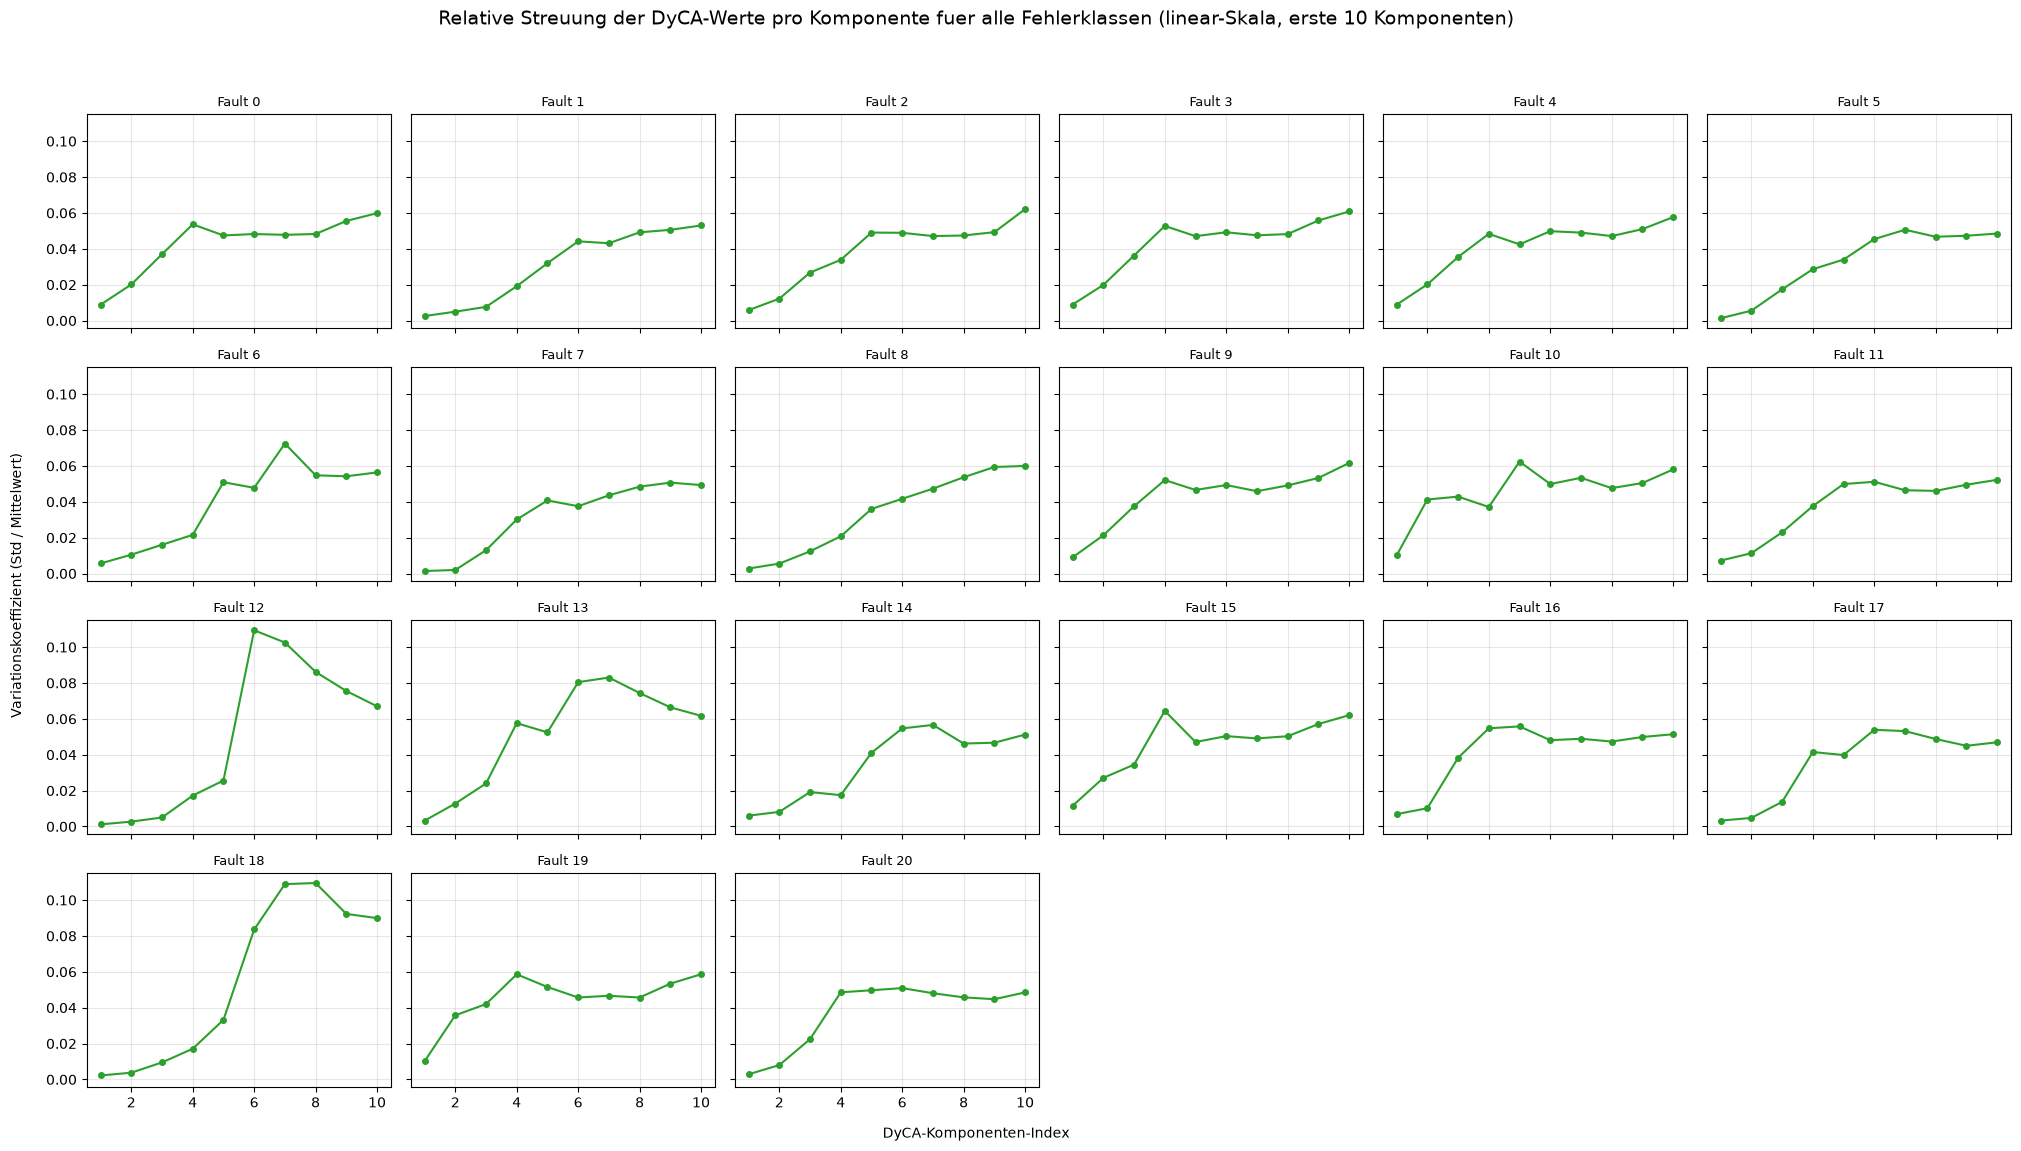

In [9]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

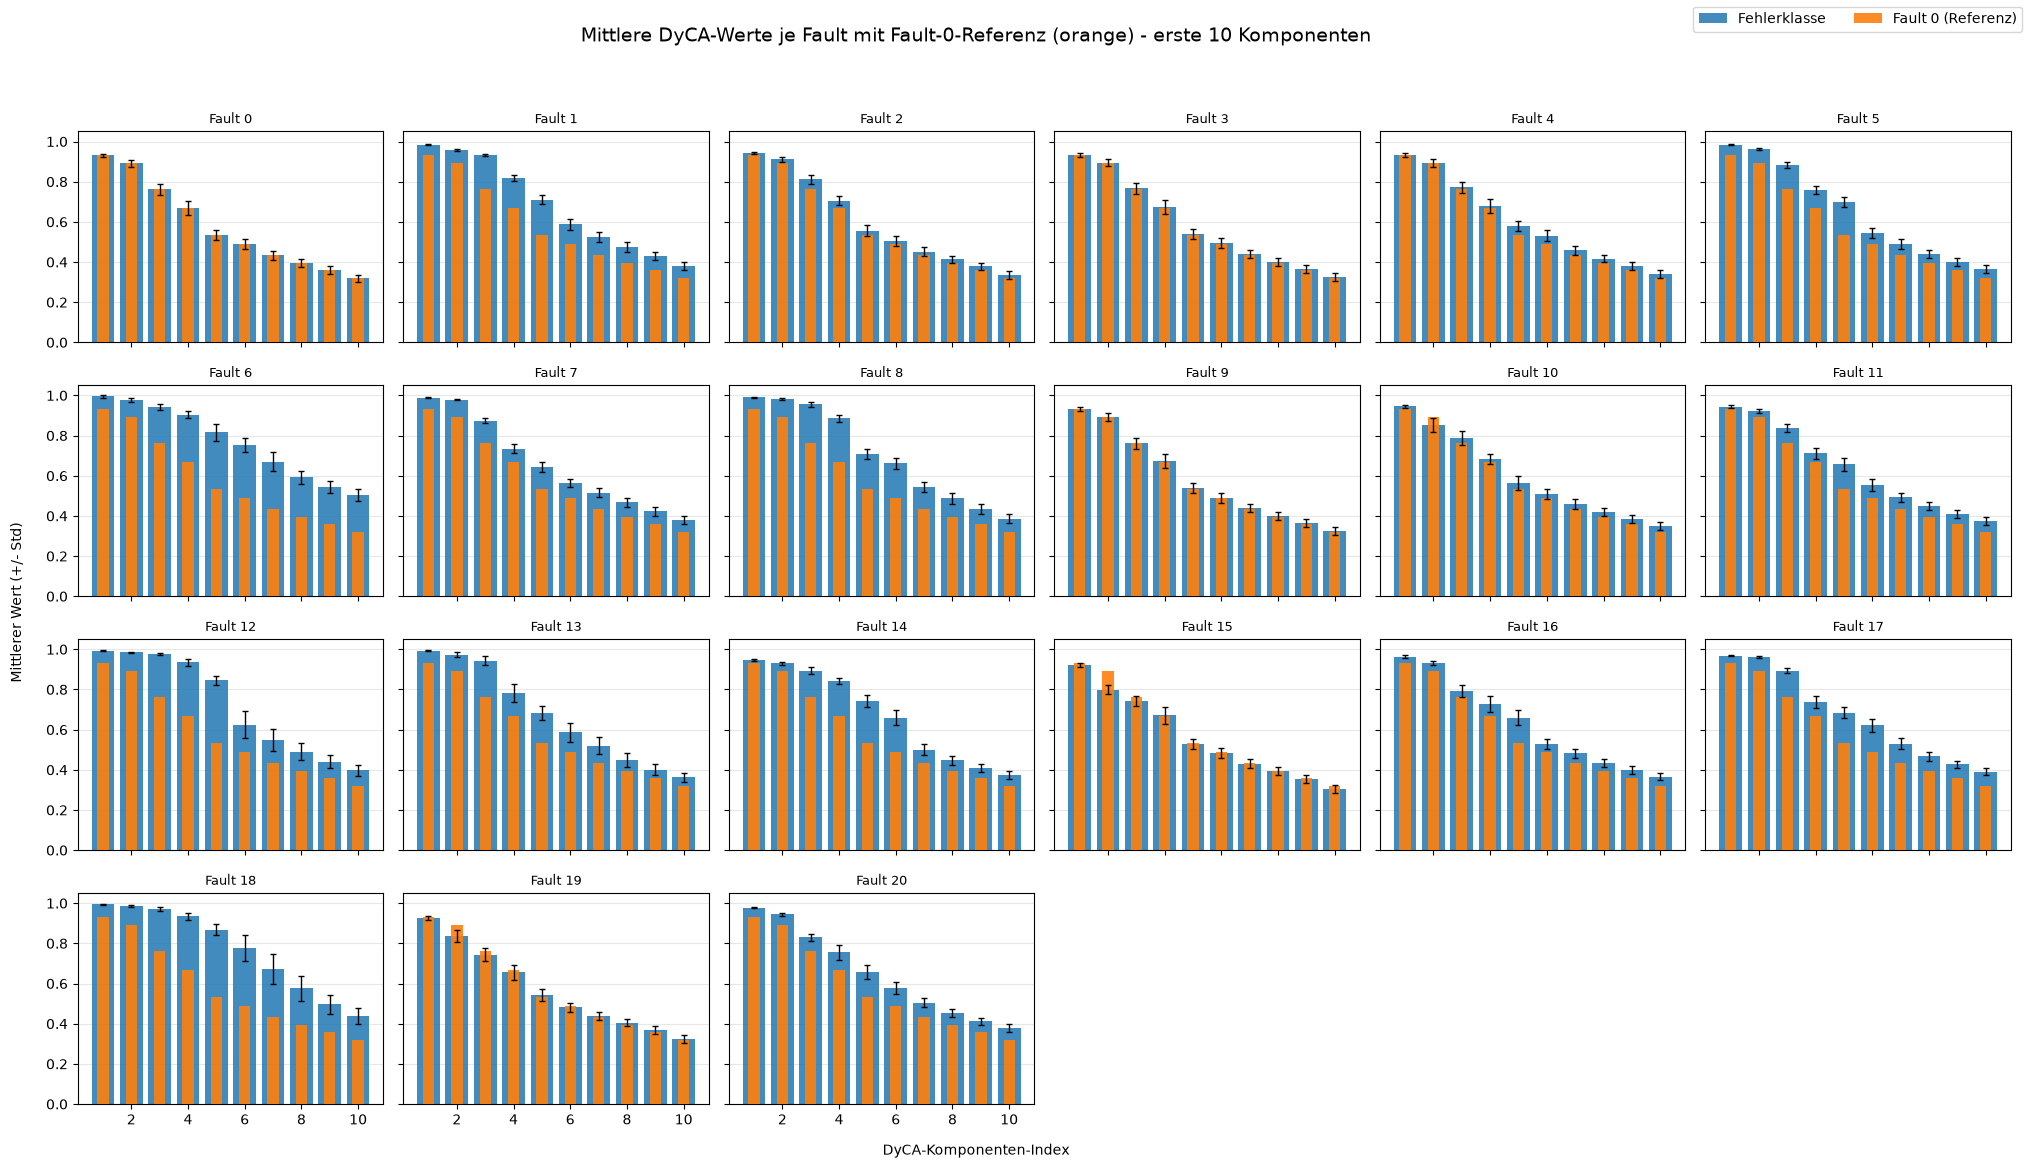

In [10]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `dyca_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [11]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

DyCA-Train gespeichert: (10038, 54) -> .\dyca_eigenvalues_train.csv


'.\\dyca_eigenvalues_train.csv'